<a href="https://colab.research.google.com/github/NeeharikaReddy7726/AI-Lab/blob/main/ai_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

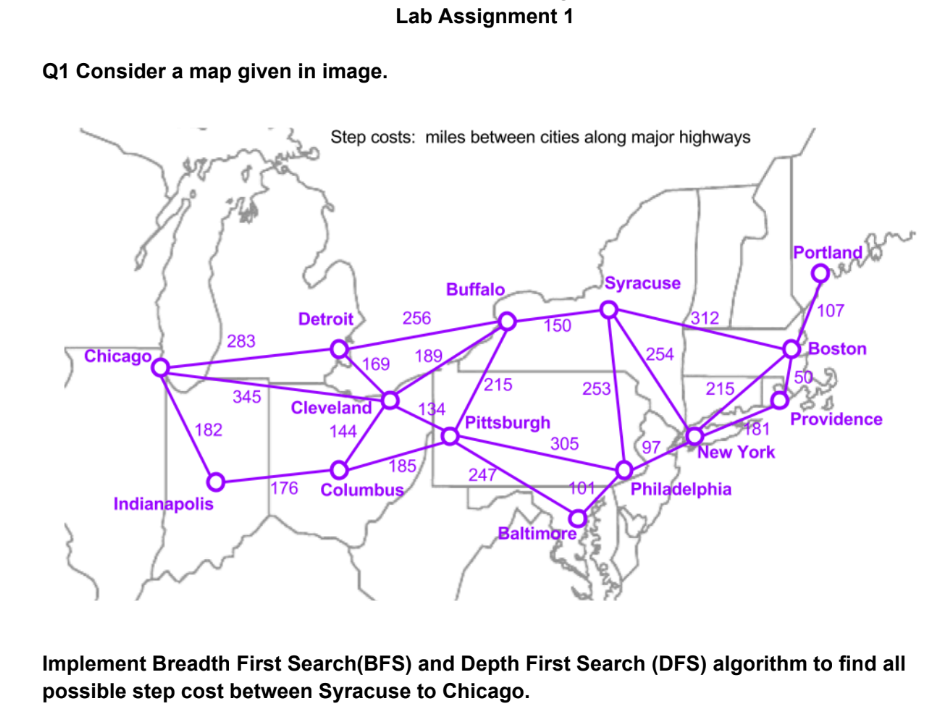

In [ ]:
graph = {
    "Portland": [("Boston", 107)],
    "Boston": [("Portland", 107),("Providence", 50), ("Syracuse", 312), ("Newyork", 215)],
    "Syracuse": [("Buffalo", 150), ("Philadelphia", 253), ("Newyork", 254), ("Boston", 312)],
    "Providence": [("Boston", 50), ("Newyork", 181)],
    "Newyork": [("Providence",181), ("Syracuse",254), ("Philadelphia", 97), ("Boston", 215)],
    "Philadelphia": [("Syracuse", 253), ("Newyork", 97), ("Pittsburgh", 305), ("Baltimore", 101)],
    "Baltimore": [("Philadelphia", 101), ("Pittsburgh", 247)],
    "Pittsburgh": [("Philadelphia", 305), ("Baltimore", 247), ("Buffalo", 215), ("Cleveland", 134), ("Columbus", 185)],
    "Buffalo": [("Cleveland", 189), ("Pittsburgh", 215), ("Syracuse", 150),("Detroit", 256)],
    "Cleveland": [("Columbus", 144), ("Detroit", 169), ("Chicago", 345), ("Buffalo", 189),("Pittsburgh", 134)],
    "Detroit": [("Chicago", 283), ("Cleveland", 169), ("Buffalo", 256)],
    "Columbus": [("Indianapolis", 176), ("Cleveland", 144), ("Pittsburgh", 185)],
    "Indianapolis": [("Chicago", 182), ("Columbus", 176)],
    "Chicago": [("Indianapolis", 182), ("Cleveland", 345), ("Detroit", 283)],

}


Algorithm for BFS implementation

In [ ]:
from collections import deque

def bfs_paths(graph, start, goal):
    queue = deque([(start, [start], 0)])  # current city, path so far, cost so far
    all_paths = []

    while queue:
        city, path, cost = queue.popleft()
        if city == goal:
            all_paths.append((path, cost))
            continue
        for neighbor, step_cost in graph.get(city, []):
            if neighbor not in path:  # avoid cycles
                queue.append((neighbor, path + [neighbor], cost + step_cost))
    return all_paths


In [ ]:
bfs_results = bfs_paths(graph, "Syracuse", "Chicago")
print("BFS Paths from Syracuse to Chicago:")
for path, cost in bfs_results:
  print(f"Path: {' -> '.join(path)}, Cost: {cost} miles")

BFS Paths from Syracuse to Chicago:
Path: Syracuse -> Buffalo -> Cleveland -> Chicago, Cost: 684 miles
Path: Syracuse -> Buffalo -> Detroit -> Chicago, Cost: 689 miles
Path: Syracuse -> Buffalo -> Cleveland -> Detroit -> Chicago, Cost: 791 miles
Path: Syracuse -> Buffalo -> Pittsburgh -> Cleveland -> Chicago, Cost: 844 miles
Path: Syracuse -> Buffalo -> Detroit -> Cleveland -> Chicago, Cost: 920 miles
Path: Syracuse -> Philadelphia -> Pittsburgh -> Cleveland -> Chicago, Cost: 1037 miles
Path: Syracuse -> Buffalo -> Cleveland -> Columbus -> Indianapolis -> Chicago, Cost: 841 miles
Path: Syracuse -> Buffalo -> Pittsburgh -> Cleveland -> Detroit -> Chicago, Cost: 951 miles
Path: Syracuse -> Buffalo -> Pittsburgh -> Columbus -> Indianapolis -> Chicago, Cost: 908 miles
Path: Syracuse -> Buffalo -> Pittsburgh -> Columbus -> Cleveland -> Chicago, Cost: 1039 miles
Path: Syracuse -> Philadelphia -> Pittsburgh -> Buffalo -> Cleveland -> Chicago, Cost: 1307 miles
Path: Syracuse -> Philadelphia ->

Algorithm for DFS Implementation

In [ ]:
def dfs_paths(graph, start, goal):
    stack = [(start, [start], 0)]
    all_paths = []

    while stack:
        city, path, cost = stack.pop()
        if city == goal:
            all_paths.append((path, cost))
            continue
        for neighbor, step_cost in graph.get(city, []):
            if neighbor not in path:
                stack.append((neighbor, path + [neighbor], cost + step_cost))
    return all_paths


In [ ]:
dfs_results = dfs_paths(graph, "Syracuse", "Chicago")
print("\nDFS Paths from Syracuse to Chicago:")
for path, cost in dfs_results:
  print(f"Path: {' -> '.join(path)}, Cost: {cost} miles")


DFS Paths from Syracuse to Chicago:
Path: Syracuse -> Boston -> Newyork -> Philadelphia -> Baltimore -> Pittsburgh -> Columbus -> Cleveland -> Buffalo -> Detroit -> Chicago, Cost: 2029 miles
Path: Syracuse -> Boston -> Newyork -> Philadelphia -> Baltimore -> Pittsburgh -> Columbus -> Cleveland -> Chicago, Cost: 1646 miles
Path: Syracuse -> Boston -> Newyork -> Philadelphia -> Baltimore -> Pittsburgh -> Columbus -> Cleveland -> Detroit -> Chicago, Cost: 1753 miles
Path: Syracuse -> Boston -> Newyork -> Philadelphia -> Baltimore -> Pittsburgh -> Columbus -> Indianapolis -> Chicago, Cost: 1515 miles
Path: Syracuse -> Boston -> Newyork -> Philadelphia -> Baltimore -> Pittsburgh -> Cleveland -> Buffalo -> Detroit -> Chicago, Cost: 1834 miles
Path: Syracuse -> Boston -> Newyork -> Philadelphia -> Baltimore -> Pittsburgh -> Cleveland -> Chicago, Cost: 1451 miles
Path: Syracuse -> Boston -> Newyork -> Philadelphia -> Baltimore -> Pittsburgh -> Cleveland -> Detroit -> Chicago, Cost: 1558 miles

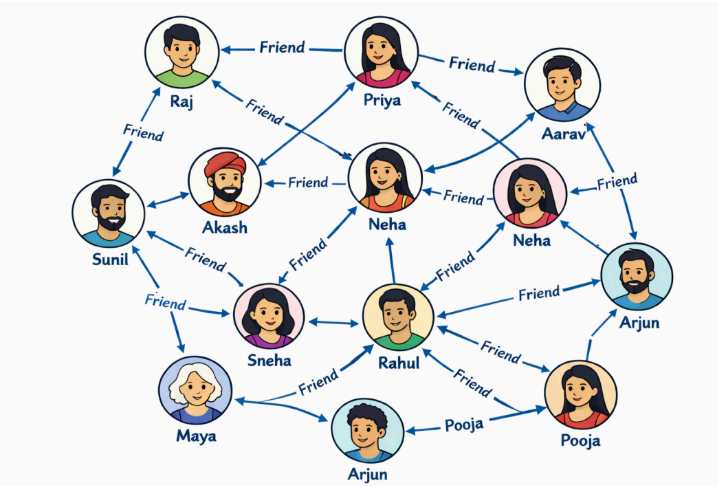

Q2 Consider a social media network as given above. Find BFS and DFS tree.

In [ ]:
social_graph = {
    "Raj": ["Priya", "Aarav","Sunil"],
    "Priya": ["Raj", "Akash", "Neha2", "Aarav"],
    "Sunil": ["Raj", "Akash", "Sneha", "Maya"],
    "Aarav": ["Priya", "Neha", "Arjun2"],
    "Akash": ["Neha", "Priya", "Sunil"],
    "Neha": ["Rahul","Sneha", "Neha2", "Aarav", "Akash"],
    "Neha2":["Neha", "Rahul", "Arjun", "Priya"],
    "Sneha": ["Neha", "Sunil", "Rahul"],
    "Rahul": ["Pooja", "Sneha", "Neha2", "Neha","Maya", "Arjun2"],
    "Maya": ["Rahul", "Arjun", "Sunil"],
    "Arjun": ["Pooja", "Maya"],
    "Pooja": [],
    "Arjun2":["Aarav", "Neha2", "Rahul", "Pooja"],
}


Algorithm for BFS implementation

In [ ]:
from collections import deque

def bfs_tree(graph, start):
    visited = set()
    tree = {}
    queue = deque([start])
    visited.add(start)
    tree[start] = []

    while queue:
        node = queue.popleft()
        for neighbor in graph.get(node, []):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
                tree.setdefault(node, []).append(neighbor)
                tree.setdefault(neighbor, [])
    return tree


In [ ]:
# Run BFS Tree
bfs_result = bfs_tree(social_graph, "Raj")
print("BFS Tree:")
for parent, children in bfs_result.items():
    print(f"{parent} -> {children}")


BFS Tree:
Raj -> ['Priya', 'Aarav', 'Sunil']
Priya -> ['Akash', 'Neha2']
Aarav -> ['Neha', 'Arjun2']
Sunil -> ['Sneha', 'Maya']
Akash -> []
Neha2 -> ['Rahul', 'Arjun']
Neha -> []
Arjun2 -> ['Pooja']
Sneha -> []
Maya -> []
Rahul -> []
Arjun -> []
Pooja -> []


Algorithm for DFS implementation

In [ ]:
def dfs_tree(graph, start):
    visited = set()
    tree = {}

    def dfs(node):
        visited.add(node)
        tree.setdefault(node, [])
        for neighbor in graph.get(node, []):
            if neighbor not in visited:
                tree[node].append(neighbor)
                dfs(neighbor)

    dfs(start)
    return tree


In [ ]:
# Run DFS Tree
dfs_result = dfs_tree(social_graph, "Raj")
print("\nDFS Tree:")
for parent, children in dfs_result.items():
    print(f"{parent} -> {children}")


NameError: name 'dfs_tree' is not defined